In [1]:
library(dplyr)
library(zoo)

nasa_ntl <- read.csv("NASA_ntl_2012_2024_monthly.csv", stringsAsFactors = FALSE)

nasa_ntl <- nasa_ntl %>%
    mutate(date = as.yearmon(date, "%Y-%m"))

nasa_ntl_odd <- nasa_ntl %>%
    filter(as.numeric(format(date, "%m")) %in% c(1, 3, 5, 7, 9, 11))

vancouver_ntl <- nasa_ntl_odd %>%
    group_by(date) %>%
    summarise(
        total_ntl = sum(n_non_na_pixels * ntl_mean, na.rm = TRUE),
        total_pixels = sum(n_non_na_pixels, na.rm = TRUE),
        .groups = "drop"
    ) %>%
    mutate(weighted_ntl_mean = total_ntl / total_pixels) %>%
    arrange(date) %>%
    mutate(
        prev_weighted_ntl_mean = lag(weighted_ntl_mean),
        total_ntl = 100 * (weighted_ntl_mean - prev_weighted_ntl_mean) / prev_weighted_ntl_mean
    )

write.csv(vancouver_ntl, "ntl_vancouver_monthly_total_ntl.csv", row.names = FALSE)

print(vancouver_ntl)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




# A tibble: 78 × 5
   date      total_ntl total_pixels weighted_ntl_mean prev_weighted_ntl_mean
   <yearmon>     <dbl>        <int>             <dbl>                  <dbl>
 1 Jan 2012      NA            3650              4.52                  NA   
 2 Mar 2012       9.51         3853              4.95                   4.52
 3 May 2012      -3.79         3868              4.76                   4.95
 4 Jul 2012       1.88         3868              4.85                   4.76
 5 Sep 2012       9.77         3868              5.33                   4.85
 6 Nov 2012     -24.6          3434              4.02                   5.33
 7 Jan 2013     -13.9          3862              3.46                   4.02
 8 Mar 2013      78.6          3861              6.18                   3.46
 9 May 2013      -5.98         3865              5.81                   6.18
10 Jul 2013       2.81         3825              5.97                   5.81
# ℹ 68 more rows


In [2]:
library(tidyverse)
library(strucchange)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: sandwich


Attaching package: ‘strucchange’


The following object is masked from ‘package:stringr’:

    boundary




In [3]:
library(readr)
library(dplyr)
library(strucchange)
library(doParallel)
library(foreach)

# Load and prepare data
data <- read_csv('ntl_2012_2024_daily.csv') %>%
  drop_na() %>%
  arrange(date) %>%
  mutate(date = as.Date(date, "%Y-%m-%d"),
         time_index = row_number())

# Setup parallel backend: use one less than the total available cores
cores <- parallel::detectCores() - 1
cl <- makeCluster(cores)
registerDoParallel(cl)

# Example: try multiple minimum segment sizes (h) in parallel
h_values <- c(10, 15, 20)  # you can adjust these as needed

# Compute breakpoint models in parallel for each h value
bp_models <- foreach(h_val = h_values, .packages = 'strucchange') %dopar% {
  breakpoints(ntl_mean ~ time_index, data = data, h = h_val)
}

# Select one model (e.g., the one with h = 10)
bp_model <- bp_models[[1]]

# Stop the cluster when done
stopCluster(cl)

# Review and plot the chosen model
print(summary(bp_model))
plot(bp_model)

# Get fitted values and breakpoints
fitted_vals <- fitted(bp_model)
break_inds <- bp_model$breakpoints
break_dates <- data$date[break_inds]
print(break_dates)

# Plot the original series with fitted values and breakpoints
plot(data$date, data$ntl_mean, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "Total NTL with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)
abline(v = break_dates, col = "blue", lty = 2)

Loading required package: foreach


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators



Loading required package: parallel

Rows: 4749 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
data <- read_csv('ntl_2012_2024_daily.csv')|>
drop_na()
print(data)

data <- data[order(data$date), ]
data <- na.omit(data)
data$date <- as.Date(data$date, format = "%Y-%m-%d") 

data$time_index <- seq_len(nrow(data))
# Assuming you want each segment to have at least 10 observations:
bp_model <- breakpoints(ntl_mean ~ time_index, data = data, h = 10)

summary(bp_model)
plot(bp_model)

fitted_vals <- fitted(bp_model)
break_inds <- bp_model$breakpoints
break_dates <- data$date[break_inds]

print(break_dates)

plot(data$date, data$ntl_mean, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

abline(v = break_dates, col = "blue", lty = 2)

Rows: 4749 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels
date (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 3,830 × 5
   ntl_mean n_pixels n_non_na_pixels prop_non_na_pixels date      
      <dbl>    <dbl>           <dbl>              <dbl> <date>    
 1     4.35      907             887              0.978 2012-01-19
 2     4.28      907             890              0.981 2012-01-20
 3     4.28      907             891              0.982 2012-01-21
 4     4.28      907             889              0.980 2012-01-22
 5     4.02      907             905              0.998 2012-01-23
 6     4.25      907             905              0.998 2012-01-24
 7     4.31      907             907              1     2012-01-25
 8     4.30      907             903              0.996 2012-01-26
 9     4.32      907             903              0.996 2012-01-27
10     4.30      907             904              0.997 2012-01-28
# ℹ 3,820 more rows


In [1]:
data <- read_csv('ntl_2012_2024_daily.csv')|>
drop_na()
print(data)

data <- data[order(data$date), ]
data <- na.omit(data)
data$date <- as.Date(data$date, format = "%Y-%m-%d") 

data$time_index <- seq_len(nrow(data))
# Assuming you want each segment to have at least 10 observations:
bp_model <- breakpoints(ntl_mean ~ time_index, data = data, h = 10)

summary(bp_model)
plot(bp_model)

fitted_vals <- fitted(bp_model)
break_inds <- bp_model$breakpoints
break_dates <- data$date[break_inds]

print(break_dates)

plot(data$date, data$ntl_mean, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

abline(v = break_dates, col = "blue", lty = 2)



ERROR: Error in drop_na(read_csv("ntl_2012_2024_daily.csv")): could not find function "drop_na"



	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = total_ntl ~ time_index, h = 0.1, 
    data = data)

Breakpoints at observation number:
                               
m = 1         30               
m = 2         30       70      
m = 3      17 30       70      
m = 4      17 30    60 70      
m = 5      17 30 43 60 70      
m = 6      17 30 43 60 70    89
m = 7   10 20 30 43 60 70    89
m = 8   10 20 30 43 60 70 80 90

Corresponding to breakdates:
                                          
m = 1            0.3                      
m = 2            0.3          0.7         
m = 3       0.17 0.3          0.7         
m = 4       0.17 0.3      0.6 0.7         
m = 5       0.17 0.3 0.43 0.6 0.7         
m = 6       0.17 0.3 0.43 0.6 0.7     0.89
m = 7   0.1 0.2  0.3 0.43 0.6 0.7     0.89
m = 8   0.1 0.2  0.3 0.43 0.6 0.7 0.8 0.9 

Fit:
                                                                  
m   0      1      2      3      4      5      6      7      8

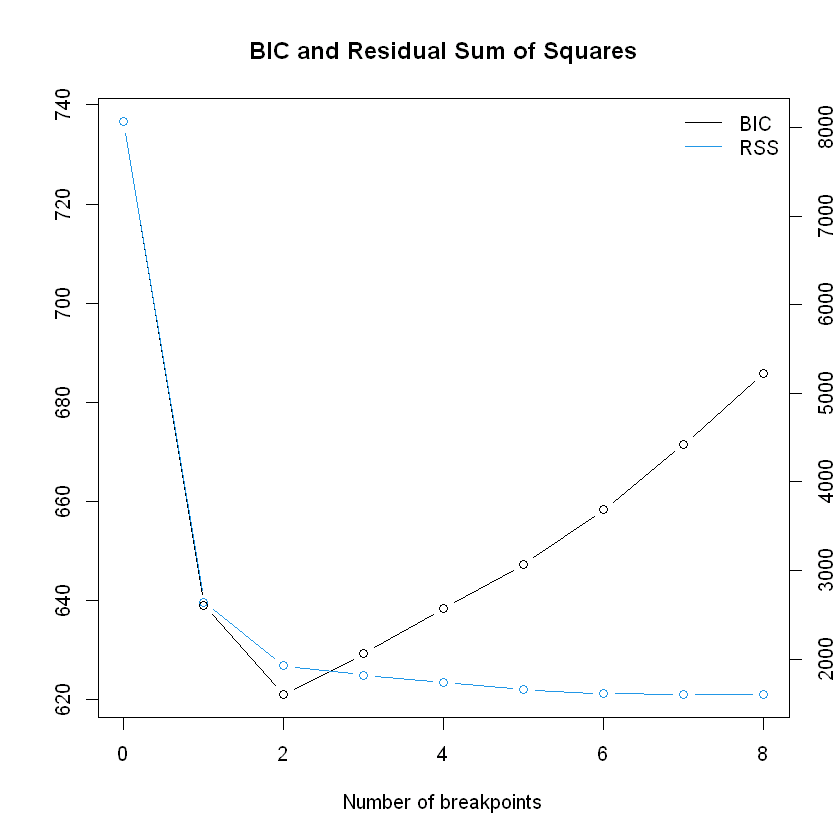

[1] "2012-06-01" "2015-10-01"


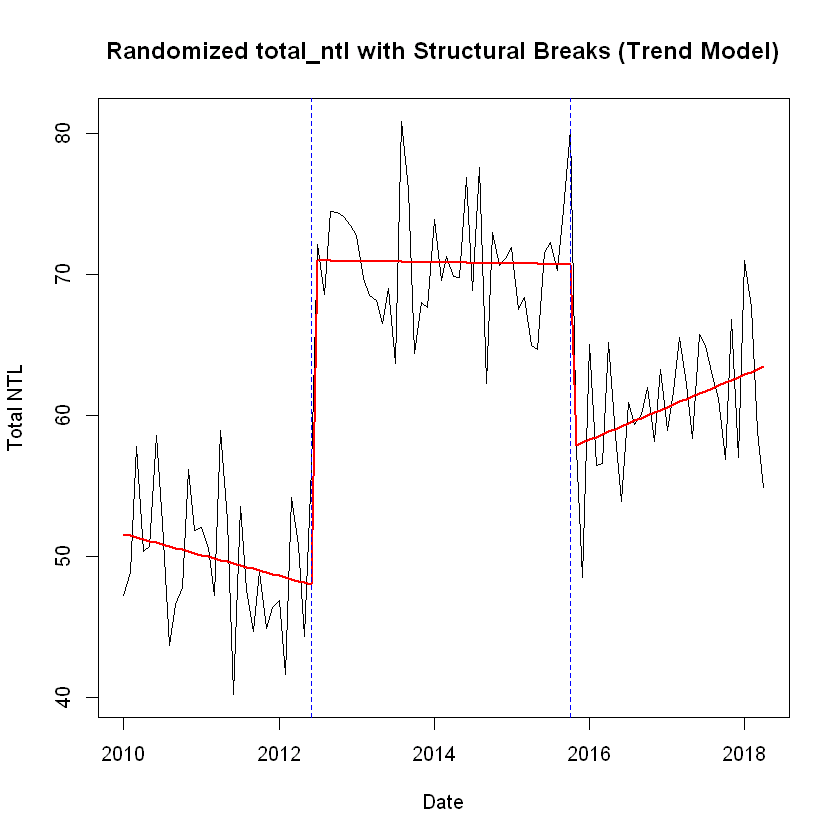

In [54]:
# Load required package
library(strucchange)

# Set seed for reproducibility
set.seed(123)

# Generate a sequence of monthly dates
n <- 100
dates <- seq(as.Date("2010-01-01"), by = "month", length.out = n)

# Simulate total_ntl values with artificial breaks:
# - First 30 observations: mean ~50
# - Next 40 observations: mean ~70
# - Last 30 observations: mean ~60
total_ntl <- c(rnorm(30, mean = 50, sd = 5),
               rnorm(40, mean = 70, sd = 5),
               rnorm(30, mean = 60, sd = 5))

# Create the data frame
data <- data.frame(date = dates, total_ntl = total_ntl)

# Sort data by date and remove any potential NAs (should be none in this simulated dataset)
data <- data[order(data$date), ]
data <- na.omit(data)

# Create a numeric time index to represent time
data$time_index <- seq_len(nrow(data))

# Fit the Bai-Perron model (adjust h as needed)
bp_model <- breakpoints(total_ntl ~ time_index, data = data, h = 0.1)
plot(bp_model)
# Print a summary of the breakpoints
summary(bp_model)

# Get the fitted piecewise regression values
fitted_vals <- fitted(bp_model)

# Plot the original total_ntl time series and the fitted piecewise regression line
plot(data$date, data$total_ntl, type = "l",
     xlab = "Date", ylab = "Total NTL",
     main = "Randomized total_ntl with Structural Breaks (Trend Model)")
lines(data$date, fitted_vals, col = "red", lwd = 2)

# Get the breakpoints indices and corresponding dates
break_inds <- bp_model$breakpoints
break_dates <- data$date[break_inds]

# Draw vertical dashed blue lines at the estimated breakpoints
abline(v = break_dates, col = "blue", lty = 2)

# Print the break dates (x positions)
print(break_dates)
